# Reading Keysight HDF5 oscilloscope files

This notebook shows the intended use of `lab_tools.io.read_keysight_h5` for segmented Keysight oscilloscope waveform files, such as the PMT calibration `run530.h5` file.

The reader returns three objects:

- `time`: the sample time axis, usually one-dimensional for relative-time overlay plots
- `voltage`: a two-dimensional array with shape `(n_waveforms, n_samples)`
- `metadata`: file, channel, and segment metadata from the HDF5 file


## Imports

`h5py` and `numpy` are Lab-tools dependencies. `matplotlib` is only used for plotting in this example notebook.

In [1]:
from pathlib import Path
import sys
import tempfile

import h5py
import numpy as np

# Let the notebook run directly from a Lab-tools source checkout without
# requiring `python -m pip install -e .` first.
for directory in [Path.cwd(), *Path.cwd().parents]:
    src_dir = directory / "src"
    if (src_dir / "lab_tools").exists():
        sys.path.insert(0, str(src_dir))
        break

from lab_tools.io import read_keysight_h5, read_segment_time_tags

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

## Find an example file

The Lab-tools repository includes `examples/data/run530_5waveforms.h5`, a reduced copy of the PMT calibration `run530.h5` file with five real Channel 1 segments and a synthetic Channel 2. If that fixture is unavailable, the next cell creates a tiny two-channel Keysight-shaped HDF5 file so the notebook remains runnable.

In [2]:
def write_demo_keysight_h5(path):
    with h5py.File(path, "w") as h5_file:
        file_type = h5_file.create_group("FileType")
        file_type.create_dataset("KeysightH5FileType", data=b"Keysight Waveform")

        frame_dtype = np.dtype([("Model", "S12"), ("Serial", "S12"), ("Date", "S22")])
        frame = h5_file.create_group("Frame")
        frame.create_dataset(
            "TheFrame",
            data=np.array((b"EXR054A", b"DEMO", b"20-Mar-2025"), dtype=frame_dtype),
        )

        waveforms = h5_file.create_group("Waveforms")
        channel_1 = waveforms.create_group("Channel 1")
        channel_1.attrs["NumPoints"] = 8
        channel_1.attrs["NumSegments"] = 3
        channel_1.attrs["XInc"] = 0.5e-9
        channel_1.attrs["XOrg"] = -1.0e-9
        channel_1.attrs["XUnits"] = b"Second"
        channel_1.attrs["YInc"] = 1.0e-3
        channel_1.attrs["YOrg"] = -10.0e-3
        channel_1.attrs["YUnits"] = b"Volt"

        channel_2 = waveforms.create_group("Channel 2")
        for key, value in channel_1.attrs.items():
            channel_2.attrs[key] = value
        channel_2.attrs["YInc"] = 1.0e-3
        channel_2.attrs["YOrg"] = 0.0

        for segment in range(1, 4):
            raw_1 = np.array([10, 11, 13, 18, 45, 20, 12, 10], dtype=np.int16) + segment
            dataset_1 = channel_1.create_dataset(f"Channel 1 Seg{segment}Data", data=raw_1)
            dataset_1.attrs["SegmentedTimeTag"] = (segment - 1) * 1.0e-3
            dataset_1.attrs["SegmentedXOrg"] = -1.0e-9
            dataset_1.attrs["RawNumPts"] = raw_1.size + 1

            raw_2 = np.zeros(raw_1.shape, dtype=np.int16)
            raw_2[3:6] = 240 + 5 * segment
            dataset_2 = channel_2.create_dataset(f"Channel 2 Seg{segment}Data", data=raw_2)
            for key, value in dataset_1.attrs.items():
                dataset_2.attrs[key] = value


candidates = [
    Path("data/run530_5waveforms.h5"),
    Path("examples/data/run530_5waveforms.h5"),
    Path("../examples/data/run530_5waveforms.h5"),
    Path("Lab-tools/examples/data/run530_5waveforms.h5"),
]

data_file = next((path for path in candidates if path.exists()), None)

if data_file is None:
    demo_dir = tempfile.TemporaryDirectory()
    data_file = Path(demo_dir.name) / "demo_keysight_scope.h5"
    write_demo_keysight_h5(data_file)
    print(f"Using generated demo file: {data_file}")
else:
    print(f"Using data file: {data_file.resolve()}")


Using data file: /Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/Lab-tools/examples/data/run530_5waveforms.h5


## Read selected waveform segments

Use `segment_numbers` for the 1-based segment numbers written by the oscilloscope. The default `time_axis="relative"` is convenient for overlaying pulses.

In [3]:
time, voltage, metadata = read_keysight_h5(
    data_file,
    channel="Channel 1",
    segment_numbers=[1, 2, 3],
)

print("time shape:   ", time.shape)
print("voltage shape:", voltage.shape)
print("segments:     ", metadata["segment_numbers"])
print("frame:        ", metadata["frame"])
print("XInc:         ", metadata["channel_attrs"]["XInc"])
print("Y units:      ", metadata["channel_attrs"]["YUnits"])

time shape:    (1600,)
voltage shape: (3, 1600)
segments:      [1, 2, 3]
frame:         {'Model': 'EXR054A', 'Serial': 'MY63310243', 'Date': '20-Mar-2025 16:46:12'}
XInc:          6.25e-11
Y units:       Volt


The voltage conversion matches the Keysight export convention:

```python
voltage = raw * YInc + YOrg
```

In [4]:
print("First five time samples:")
print(time[:5])

print("\nFirst five voltage samples from the first selected segment:")
print(voltage[0, :5])

First five time samples:
[0.000e+00 6.250e-11 1.250e-10 1.875e-10 2.500e-10]

First five voltage samples from the first selected segment:
[0.00060625 0.00058648 0.00055089 0.00053508 0.00051531]


## Read multiple channels

Keysight stores each channel as a separate group under `/Waveforms`. Read one channel at a time because each channel has its own voltage scaling and metadata. Segment numbers and time tags can then be used to line up channel data from the same acquisition.


In [5]:
segments_to_compare = [1, 2, 3]

ch1_time, ch1_voltage, ch1_metadata = read_keysight_h5(
    data_file,
    channel=1,
    segment_numbers=segments_to_compare,
)
ch2_time, ch2_voltage, ch2_metadata = read_keysight_h5(
    data_file,
    channel=2,
    segment_numbers=segments_to_compare,
)

print("channel 1:", ch1_metadata["channel"], ch1_voltage.shape, ch1_metadata["channel_attrs"]["YUnits"])
print("channel 2:", ch2_metadata["channel"], ch2_voltage.shape, ch2_metadata["channel_attrs"]["YUnits"])
print("same segments:", ch1_metadata["segment_numbers"] == ch2_metadata["segment_numbers"])
print("same time tags:", np.allclose(ch1_metadata["time_tags"], ch2_metadata["time_tags"]))
print("channel 2 max voltage per segment:", ch2_voltage.max(axis=1))


channel 1: Channel 1 (3, 1600) Volt
channel 2: Channel 2 (3, 1600) Volt
same segments: True
same time tags: True
channel 2 max voltage per segment: [0.245 0.25  0.255]


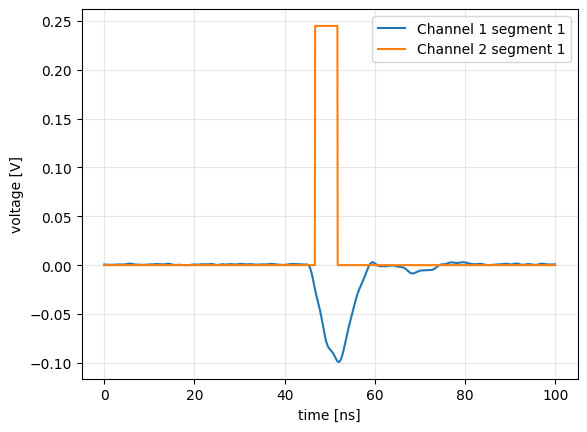

In [6]:
if plt is None:
    print("matplotlib is not installed; skipping plot")
else:
    row = 0
    segment = segments_to_compare[row]
    plt.plot(ch1_time * 1e9, ch1_voltage[row], label=f"Channel 1 segment {segment}")
    plt.plot(ch2_time * 1e9, ch2_voltage[row], label=f"Channel 2 segment {segment}")
    plt.xlabel("time [ns]")
    plt.ylabel("voltage [V]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## Plot waveforms

For the PMT file, the time axis is in seconds and is often easier to view in nanoseconds.

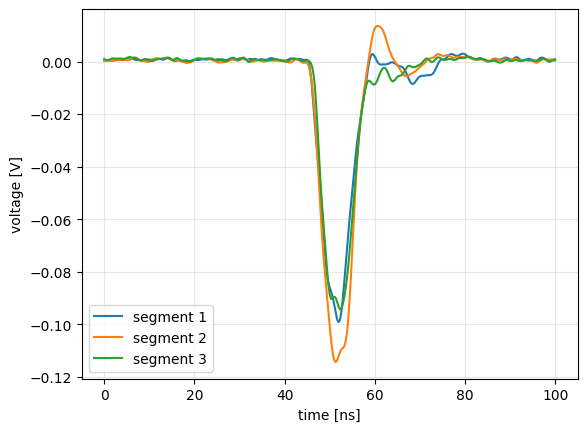

In [7]:
if plt is None:
    print("matplotlib is not installed; skipping plot")
else:
    for row, segment in enumerate(metadata["segment_numbers"]):
        plt.plot(time * 1e9, voltage[row], label=f"segment {segment}")

    plt.xlabel("time [ns]")
    plt.ylabel("voltage [V]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Use absolute segment time

Use `time_axis="absolute"` when the segment time tag matters. In that mode the reader builds:

```python
time = SegmentedTimeTag + SegmentedXOrg + sample_index * XInc
```

In [8]:
absolute_time, absolute_voltage, absolute_metadata = read_keysight_h5(
    data_file,
    segment_numbers=[1, 2, 3],
    time_axis="absolute",
)

print("absolute time shape:", absolute_time.shape)
print("first segment first time sample:", absolute_time[0, 0])
print("second segment first time sample:", absolute_time[1, 0])
print("time tags:", absolute_metadata["time_tags"])

absolute time shape: (3, 1600)
first segment first time sample: -1.387500119210247e-08
second segment first time sample: 0.0019491095296866655
time tags: [0.         0.00194912 0.00389828]


## Read only segment time tags

If you only need timing between segments, `read_segment_time_tags` avoids loading the waveform arrays.

In [9]:
segments, time_tags = read_segment_time_tags(data_file)

print("number of segments:", len(segments))
print("first segment/tag:", segments[0], time_tags[0])
print("last segment/tag: ", segments[-1], time_tags[-1])

if len(time_tags) > 1:
    print("median spacing [s]:", np.median(np.diff(time_tags)))

number of segments: 5
first segment/tag: 1 0.0
last segment/tag:  5 0.0077964492468747615
median spacing [s]: 0.0019491364921875001
